# Brainiacs AI — Misconception Classifier

**ML capstone artifact.** This notebook builds and evaluates the model behind
Brainiacs AI's *grading + misconception classification* step.

## A. Problem framing

**Task.** Given a student's conceptual / **pseudocode** answer to a programming
question, classify the **misconception** behind it (or `none` if correct). This is
the model that powers the tutor's feedback + mastery-gating loop.

**The pseudocode-only constraint.** Brainiacs AI never runs student code — students
write pseudocode and conceptual answers, never compilable code. So our target is a
*conceptual* misconception label, not a compiler/test-suite signal. There is **no
public dataset of pseudocode answers labelled with programming misconceptions**.

We therefore do two things:

1. **Validate the pipeline on established public data** — a real, labelled
   short-answer dataset (SciEntsBank) with a misconception-style multi-class
   target. This proves the TF-IDF → classifier → metrics pipeline works *today* on
   real data.
2. **Build a small, documented synthetic seed set** for *our* domain using the
   fixed misconception taxonomy, and train an initial baseline on it — honestly
   flagged as synthetic and pending replacement with real pilot data.

**Misconception taxonomy** (fixed, shared with the API; grounded in Qian & Lehman,
2017): `variable_name_semantics`, `assignment_as_equality`, `loop_boundary_offbyone`,
`loop_execution_model`, `scope_confusion`, `recursion_no_base_case`,
`recursion_state_confusion`, `array_index_value_confusion`, `boolean_logic_error`,
`algorithm_sequencing_error`, `none`.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, f1_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

# Collected for the final conclusion / README.
metrics_summary = {}
print("Environment ready.")

Environment ready.


## B. Method validation on public data (SciEntsBank)

We load **SciEntsBank** (`nkazi/SciEntsBank` on the Hugging Face Hub) — free,
frictionless, and labelled with a 5-way misconception-style scheme:
`correct`, `contradictory`, `partially_correct_incomplete`, `irrelevant`,
`non_domain`. We treat this as a real multi-class proxy for our task and show the
full pipeline: data viz → TF-IDF features → three classifiers → precision / recall /
F1 (macro + per class) → confusion matrix.

The dataset ships standard SemEval-2013 splits; we train on `train` and evaluate on
`test_ua` (**unseen answers**) — the held-out setting closest to grading new
student responses.

In [2]:
from datasets import load_dataset

ds = load_dataset("nkazi/SciEntsBank")
label_names = ds["train"].features["label"].names  # int -> name
print("Splits:", {k: len(v) for k, v in ds.items()})
print("Labels:", label_names)

def to_frame(split):
    df = ds[split].to_pandas()
    df["label_name"] = df["label"].map(lambda i: label_names[i])
    return df

train_df = to_frame("train")
eval_df = to_frame("test_ua")  # unseen answers
print(f"\ntrain={len(train_df)}  eval(test_ua)={len(eval_df)}")
train_df[["question", "reference_answer", "student_answer", "label_name"]].head(3)

Splits: {'train': 4969, 'test_ua': 540, 'test_uq': 733, 'test_ud': 4562}
Labels: ['correct', 'contradictory', 'partially_correct_incomplete', 'irrelevant', 'non_domain']

train=4969  eval(test_ua)=540


,question,reference_answer,student_answer,label_name
0,You used several methods to separate and ident...,"The water was evaporated, leaving the salt.",By letting it sit in a dish for a day.,irrelevant
1,You used several methods to separate and ident...,"The water was evaporated, leaving the salt.",Let the water evaporate and the salt is left b...,correct
2,You used several methods to separate and ident...,"The water was evaporated, leaving the salt.",The water evaporated and left salt crystals.,correct


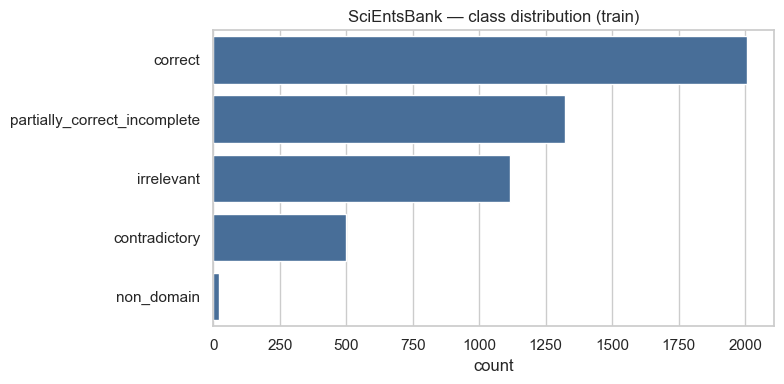

label_name
correct                         2008
partially_correct_incomplete    1324
irrelevant                      1115
contradictory                    499
non_domain                        23
Name: count, dtype: int64


In [3]:
# --- Class distribution ---
fig, ax = plt.subplots(figsize=(8, 4))
order = train_df["label_name"].value_counts().index
sns.countplot(data=train_df, y="label_name", order=order, ax=ax, color="#3b6ea5")
ax.set_title("SciEntsBank — class distribution (train)")
ax.set_xlabel("count"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(FIGURES / "scientsbank_class_distribution.png", dpi=120)
plt.show()
print(train_df["label_name"].value_counts())

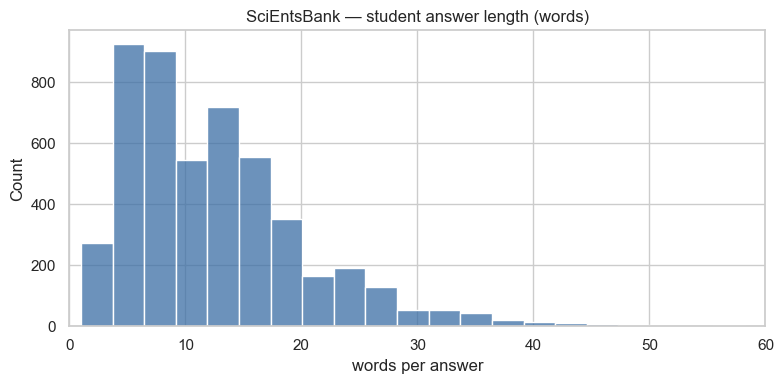

{'count': 4969.0, 'mean': 12.6, 'std': 8.2, 'min': 1.0, '25%': 7.0, '50%': 11.0, '75%': 16.0, 'max': 110.0}


In [4]:
# --- Answer-length distribution ---
train_df["answer_len"] = train_df["student_answer"].str.split().apply(len)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(train_df["answer_len"], bins=40, color="#3b6ea5", ax=ax)
ax.set_title("SciEntsBank — student answer length (words)")
ax.set_xlabel("words per answer"); ax.set_xlim(0, 60)
plt.tight_layout(); plt.savefig(FIGURES / "scientsbank_answer_length.png", dpi=120)
plt.show()
print(train_df["answer_len"].describe().round(1).to_dict())

In [5]:
# --- Features: reference answer + student answer give the model context on correctness ---
def build_text(df):
    return (df["reference_answer"].fillna("") + "  [SEP]  " + df["student_answer"].fillna("")).tolist()

X_train_text, y_train = build_text(train_df), train_df["label"].to_numpy()
X_eval_text, y_eval = build_text(eval_df), eval_df["label"].to_numpy()

def evaluate(name, pipeline):
    pipeline.fit(X_train_text, y_train)
    pred = pipeline.predict(X_eval_text)
    acc = accuracy_score(y_eval, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_eval, pred, average="macro", zero_division=0)
    print(f"{name:20s}  acc={acc:.3f}  macro-P={p:.3f}  macro-R={r:.3f}  macro-F1={f1:.3f}")
    metrics_summary[name] = {"accuracy": round(acc, 4), "macro_precision": round(p, 4),
                             "macro_recall": round(r, 4), "macro_f1": round(f1, 4)}
    return pred

models = {
    "TF-IDF + LinearSVC": make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), LinearSVC()),
    "TF-IDF + LogReg": make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        LogisticRegression(max_iter=2000, class_weight="balanced")),
}
predictions = {name: evaluate(name, pipe) for name, pipe in models.items()}

TF-IDF + LinearSVC    acc=0.561  macro-P=0.424  macro-R=0.398  macro-F1=0.403


TF-IDF + LogReg       acc=0.463  macro-P=0.372  macro-R=0.390  macro-F1=0.370


In [6]:
# --- XGBoost on the same TF-IDF features ---
from xgboost import XGBClassifier

vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
Xtr = vec.fit_transform(X_train_text)
Xev = vec.transform(X_eval_text)

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.2,
    subsample=0.9, colsample_bytree=0.8,
    objective="multi:softmax", num_class=len(label_names),
    eval_metric="mlogloss", n_jobs=4, random_state=RANDOM_STATE, tree_method="hist",
)
xgb.fit(Xtr, y_train)
pred_xgb = xgb.predict(Xev)
acc = accuracy_score(y_eval, pred_xgb)
p, r, f1, _ = precision_recall_fscore_support(y_eval, pred_xgb, average="macro", zero_division=0)
print(f"{'TF-IDF + XGBoost':20s}  acc={acc:.3f}  macro-P={p:.3f}  macro-R={r:.3f}  macro-F1={f1:.3f}")
metrics_summary["TF-IDF + XGBoost"] = {"accuracy": round(acc, 4), "macro_precision": round(p, 4),
                                       "macro_recall": round(r, 4), "macro_f1": round(f1, 4)}
predictions["TF-IDF + XGBoost"] = pred_xgb

TF-IDF + XGBoost      acc=0.594  macro-P=0.481  macro-R=0.438  macro-F1=0.450


Best public-data model: TF-IDF + XGBoost

                              precision    recall  f1-score   support

                     correct       0.66      0.70      0.68       233
               contradictory       0.68      0.40      0.50        58
partially_correct_incomplete       0.41      0.51      0.45       113
                  irrelevant       0.66      0.58      0.62       133
                  non_domain       0.00      0.00      0.00         3

                    accuracy                           0.59       540
                   macro avg       0.48      0.44      0.45       540
                weighted avg       0.61      0.59      0.59       540



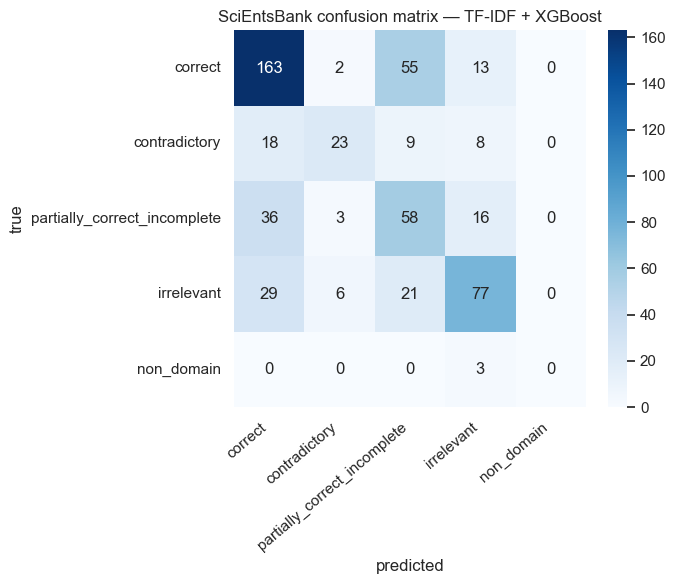

In [7]:
# --- Per-class report + confusion matrix for the best model (by macro-F1) ---
best_name = max(["TF-IDF + LinearSVC", "TF-IDF + LogReg", "TF-IDF + XGBoost"],
                key=lambda n: metrics_summary[n]["macro_f1"])
print(f"Best public-data model: {best_name}\n")
print(classification_report(y_eval, predictions[best_name], target_names=label_names, zero_division=0))

cm = confusion_matrix(y_eval, predictions[best_name])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_title(f"SciEntsBank confusion matrix — {best_name}")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.xticks(rotation=40, ha="right"); plt.tight_layout()
plt.savefig(FIGURES / "scientsbank_confusion_matrix.png", dpi=120)
plt.show()

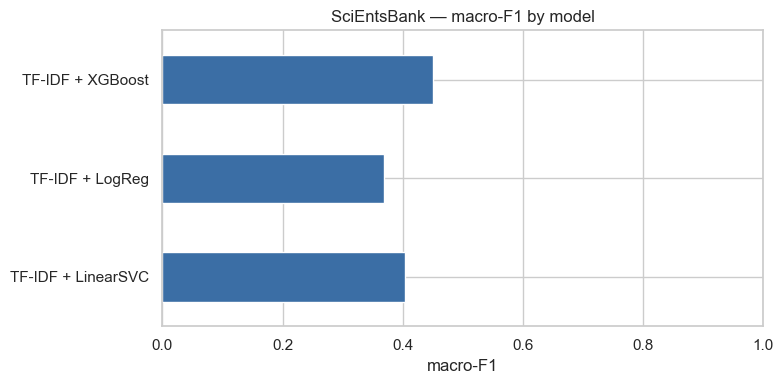

,accuracy,macro_precision,macro_recall,macro_f1
TF-IDF + LinearSVC,0.561,0.424,0.398,0.403
TF-IDF + LogReg,0.463,0.372,0.390,0.370
TF-IDF + XGBoost,0.594,0.481,0.438,0.450


In [8]:
# --- Model comparison (macro-F1) ---
comp = pd.DataFrame(metrics_summary).T[["accuracy", "macro_precision", "macro_recall", "macro_f1"]]
fig, ax = plt.subplots(figsize=(8, 4))
comp["macro_f1"].plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_title("SciEntsBank — macro-F1 by model"); ax.set_xlabel("macro-F1"); ax.set_xlim(0, 1)
plt.tight_layout(); plt.savefig(FIGURES / "scientsbank_model_comparison.png", dpi=120)
plt.show()
comp.round(3)

## C. The real task — a synthetic seed set

No public dataset maps **pseudocode answers → programming misconceptions**, so we
author a small **synthetic seed set** in our own schema and taxonomy. Each row is a
question, a reference answer, and a student *pseudocode* answer written to embody a
specific misconception (or a correct answer labelled `none`).

> ⚠️ **Honesty note.** This seed set is **synthetic** and small. It is a
> bootstrapping device, *not* validated training data. Before it can support
> production claims it must be replaced/augmented with **real pilot data** and
> checked for **inter-annotator agreement** (Cohen's κ) across independent
> annotators. Numbers from a model trained on this set are *indicative only*.

The cell below contains a hand-authored seed (`source = "synthetic_seed"`). An
optional Anthropic-API augmentation step (next markdown cell) scales this toward
the ~80–120 row target by prompting Claude to "answer as a novice who believes
<misconception>".

In [9]:
SEED_ROWS = [
    # ---------------- variable_name_semantics ----------------
    {"concept": "variables", "question": "Does the computer understand what the variable named 'total' is for?",
     "reference_answer": "No — the name is only a label for humans; the stored value is what matters.",
     "student_pseudocode_answer": "Yes, because it is called 'total' the computer knows to add things into it.",
     "is_correct": False, "misconception_label": "variable_name_semantics",
     "explanation": "Believes the computer reads meaning from the variable's name."},
    {"concept": "variables", "question": "If I rename 'speed' to 'x', does the program behave differently?",
     "reference_answer": "No — names are arbitrary labels; behaviour depends on values and operations.",
     "student_pseudocode_answer": "Yes, 'speed' makes it go faster than 'x' would.",
     "is_correct": False, "misconception_label": "variable_name_semantics",
     "explanation": "Attaches real-world meaning of the identifier to program behaviour."},
    {"concept": "variables", "question": "A variable is named 'isReady'. What makes it true or false?",
     "reference_answer": "Whatever boolean value is assigned to it.",
     "student_pseudocode_answer": "It is true automatically because the name says it is ready.",
     "is_correct": False, "misconception_label": "variable_name_semantics",
     "explanation": "Thinks the name 'isReady' sets the value rather than an assignment."},

    # ---------------- assignment_as_equality ----------------
    {"concept": "variables", "question": "x <- 3\\ny <- x\\nx <- 10\\nWhat is y now?",
     "reference_answer": "3 — y received a copy of x's value at assignment time.",
     "student_pseudocode_answer": "y is 10 because y equals x and x became 10.",
     "is_correct": False, "misconception_label": "assignment_as_equality",
     "explanation": "Treats assignment as a permanent equation linking the two variables."},
    {"concept": "variables", "question": "What does count <- count + 1 do?",
     "reference_answer": "Stores the current value of count plus one back into count.",
     "student_pseudocode_answer": "It is impossible, count cannot equal count plus 1.",
     "is_correct": False, "misconception_label": "assignment_as_equality",
     "explanation": "Reads '<-' as algebraic equality instead of store-into."},
    {"concept": "control-flow", "question": "Which operator compares two values for equality?",
     "reference_answer": "= (comparison); storing a value uses <-.",
     "student_pseudocode_answer": "Use <- to check if two values are equal.",
     "is_correct": False, "misconception_label": "assignment_as_equality",
     "explanation": "Confuses assignment with the equality comparison."},
    {"concept": "variables", "question": "a <- 5\\nb <- 2\\na <- a + b\\nWhat is a?",
     "reference_answer": "7 — a is reassigned to its old value plus b.",
     "student_pseudocode_answer": "a stays 5 because a already equals 5.",
     "is_correct": False, "misconception_label": "assignment_as_equality",
     "explanation": "Does not see assignment as overwriting the variable."},

    # ---------------- loop_boundary_offbyone ----------------
    {"concept": "loops", "question": "How many times does FOR i FROM 1 TO 5 run its body?",
     "reference_answer": "5 times.",
     "student_pseudocode_answer": "4 times, because you stop before 5.",
     "is_correct": False, "misconception_label": "loop_boundary_offbyone",
     "explanation": "Off-by-one: drops the final inclusive iteration."},
    {"concept": "loops", "question": "count <- 0\\nFOR i FROM 0 TO 4 DO count <- count + 1\\nWhat is count?",
     "reference_answer": "5 — the loop runs for 0,1,2,3,4.",
     "student_pseudocode_answer": "4, since it goes 1,2,3,4.",
     "is_correct": False, "misconception_label": "loop_boundary_offbyone",
     "explanation": "Miscounts an inclusive range starting at 0."},
    {"concept": "loops", "question": "FOR i FROM 1 TO n prints i. For n=3, what prints?",
     "reference_answer": "1 2 3.",
     "student_pseudocode_answer": "1 2, it stops one before n.",
     "is_correct": False, "misconception_label": "loop_boundary_offbyone",
     "explanation": "Treats the upper bound as exclusive when it is inclusive."},

    # ---------------- loop_execution_model ----------------
    {"concept": "loops", "question": "total <- 0\\nFOR i FROM 1 TO 3 DO total <- total + i\\nWhat is total?",
     "reference_answer": "6 — body runs once per iteration: 1, then 3, then 6.",
     "student_pseudocode_answer": "3, the loop adds i once at the end as 0+3.",
     "is_correct": False, "misconception_label": "loop_execution_model",
     "explanation": "Thinks the loop body runs once rather than each iteration."},
    {"concept": "loops", "question": "In a loop, does the body run all iterations at once or one at a time?",
     "reference_answer": "One iteration at a time, in sequence.",
     "student_pseudocode_answer": "All at once, the whole loop happens in a single step.",
     "is_correct": False, "misconception_label": "loop_execution_model",
     "explanation": "Holds a parallel/instant model of iteration."},
    {"concept": "loops", "question": "x <- 1\\nFOR i FROM 1 TO 3 DO x <- x * 2\\nWhat is x?",
     "reference_answer": "8 — doubles three times: 2, 4, 8.",
     "student_pseudocode_answer": "2 because it doubles once for the whole loop.",
     "is_correct": False, "misconception_label": "loop_execution_model",
     "explanation": "Applies the body a single time instead of per iteration."},

    # ---------------- scope_confusion ----------------
    {"concept": "functions", "question": "A variable created inside a function — where is it visible?",
     "reference_answer": "Only inside that function (it is local).",
     "student_pseudocode_answer": "Everywhere in the program, all variables are global.",
     "is_correct": False, "misconception_label": "scope_confusion",
     "explanation": "Treats local variables as globally visible."},
    {"concept": "functions", "question": "In square(4), what is 4 called?",
     "reference_answer": "An argument (the parameter n receives it).",
     "student_pseudocode_answer": "It is the parameter, same thing as n's definition.",
     "is_correct": False, "misconception_label": "scope_confusion",
     "explanation": "Conflates parameter (definition) with argument (call value)."},
    {"concept": "functions", "question": "FUNCTION f() sets temp <- 5. Can code outside f read temp?",
     "reference_answer": "No — temp is local to f.",
     "student_pseudocode_answer": "Yes, temp is available after f runs.",
     "is_correct": False, "misconception_label": "scope_confusion",
     "explanation": "Expects local state to leak into the outer scope."},

    # ---------------- recursion_no_base_case ----------------
    {"concept": "recursion", "question": "What does every recursion need to avoid running forever?",
     "reference_answer": "A base case that stops the recursion.",
     "student_pseudocode_answer": "It just needs to call itself; it will stop on its own.",
     "is_correct": False, "misconception_label": "recursion_no_base_case",
     "explanation": "Omits the terminating base case."},
    {"concept": "recursion", "question": "FUNCTION f(n) RETURN n + f(n-1). What happens for f(3)?",
     "reference_answer": "Infinite recursion — there is no base case to stop it.",
     "student_pseudocode_answer": "It returns 6 and stops.",
     "is_correct": False, "misconception_label": "recursion_no_base_case",
     "explanation": "Assumes recursion halts without an explicit base case."},
    {"concept": "recursion", "question": "Write the first line a factorial function needs.",
     "reference_answer": "IF n = 0 THEN RETURN 1  (the base case).",
     "student_pseudocode_answer": "RETURN n * factorial(n - 1) as the only line.",
     "is_correct": False, "misconception_label": "recursion_no_base_case",
     "explanation": "Provides the recursive step but no base case."},

    # ---------------- recursion_state_confusion ----------------
    {"concept": "recursion", "question": "FUNCTION fact(n): IF n=0 RETURN 1; RETURN n*fact(n-1). What is fact(3)?",
     "reference_answer": "6 — 3*2*1.",
     "student_pseudocode_answer": "3, the function only multiplies the first n.",
     "is_correct": False, "misconception_label": "recursion_state_confusion",
     "explanation": "Misunderstands how returns unwind and combine."},
    {"concept": "recursion", "question": "countdown(n): IF n=0 RETURN; PRINT n; countdown(n-1). Output for countdown(3)?",
     "reference_answer": "3 2 1.",
     "student_pseudocode_answer": "3, it prints once then returns.",
     "is_correct": False, "misconception_label": "recursion_state_confusion",
     "explanation": "Does not track repeated recursive calls and their state."},
    {"concept": "recursion", "question": "How many times is fact called for fact(3)?",
     "reference_answer": "4 times: fact(3), fact(2), fact(1), fact(0).",
     "student_pseudocode_answer": "Once, recursion is a single call.",
     "is_correct": False, "misconception_label": "recursion_state_confusion",
     "explanation": "Treats recursion as one call rather than a chain of frames."},

    # ---------------- array_index_value_confusion ----------------
    {"concept": "loops", "question": "Array A = [10, 20, 30]. What is A[0]?",
     "reference_answer": "10 — index 0 holds the first value.",
     "student_pseudocode_answer": "0, because the index is 0.",
     "is_correct": False, "misconception_label": "array_index_value_confusion",
     "explanation": "Returns the index instead of the value at that index."},
    {"concept": "loops", "question": "Array A = [5, 6, 7]. What is A[1]?",
     "reference_answer": "6 — the second element (0-based).",
     "student_pseudocode_answer": "5, the first element, since counting starts at 1.",
     "is_correct": False, "misconception_label": "array_index_value_confusion",
     "explanation": "Assumes 1-based indexing instead of 0-based."},
    {"concept": "loops", "question": "To get the value 30 from A = [10,20,30], which index?",
     "reference_answer": "A[2].",
     "student_pseudocode_answer": "A[30], you index by the value.",
     "is_correct": False, "misconception_label": "array_index_value_confusion",
     "explanation": "Indexes by value rather than position."},

    # ---------------- boolean_logic_error ----------------
    {"concept": "control-flow", "question": "x <- 5. Is (x > 2 AND x < 4) true?",
     "reference_answer": "False — x is not less than 4.",
     "student_pseudocode_answer": "True, because x > 2 is true.",
     "is_correct": False, "misconception_label": "boolean_logic_error",
     "explanation": "Treats AND as if one true operand suffices."},
    {"concept": "control-flow", "question": "When is (A OR B) true?",
     "reference_answer": "When at least one of A or B is true.",
     "student_pseudocode_answer": "Only when both A and B are true.",
     "is_correct": False, "misconception_label": "boolean_logic_error",
     "explanation": "Confuses OR with AND semantics."},
    {"concept": "control-flow", "question": "temperature <- 20. IF temperature > 30 print 'hot' else 'mild'. Output?",
     "reference_answer": "mild.",
     "student_pseudocode_answer": "hot, the IF always runs its first branch.",
     "is_correct": False, "misconception_label": "boolean_logic_error",
     "explanation": "Ignores the condition and assumes the THEN branch runs."},

    # ---------------- algorithm_sequencing_error ----------------
    {"concept": "algorithmic-thinking", "question": "Order the make-tea steps correctly.",
     "reference_answer": "Boil water; put teabag in cup; pour water; remove teabag.",
     "student_pseudocode_answer": "Pour water; boil water; remove teabag; put teabag in cup.",
     "is_correct": False, "misconception_label": "algorithm_sequencing_error",
     "explanation": "Steps are out of a valid causal order."},
    {"concept": "algorithmic-thinking", "question": "To swap a and b, what order of steps works (with temp)?",
     "reference_answer": "temp <- a; a <- b; b <- temp.",
     "student_pseudocode_answer": "a <- b; b <- a (no temp).",
     "is_correct": False, "misconception_label": "algorithm_sequencing_error",
     "explanation": "Wrong swap mechanics — overwrites a before saving it."},
    {"concept": "functions", "question": "Order: define double(n); call it; print result. Which comes first?",
     "reference_answer": "Define the function, then call it, then print.",
     "student_pseudocode_answer": "Print result first, then define and call double.",
     "is_correct": False, "misconception_label": "algorithm_sequencing_error",
     "explanation": "Sequences use of a result before it is produced."},

    # ---------------- none (correct answers across concepts) ----------------
    {"concept": "variables", "question": "x <- 3\\ny <- x\\nx <- 10\\nWhat is y?",
     "reference_answer": "3.", "student_pseudocode_answer": "y is 3 because it copied x's value before x changed.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "variables", "question": "What does count <- count + 1 do?",
     "reference_answer": "Stores count plus one back into count.",
     "student_pseudocode_answer": "It increases count by one and stores it back.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "loops", "question": "How many times does FOR i FROM 1 TO 5 run?",
     "reference_answer": "5.", "student_pseudocode_answer": "5 times, 1 through 5 inclusive.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "loops", "question": "total <- 0\\nFOR i FROM 1 TO 3 DO total <- total + i\\nWhat is total?",
     "reference_answer": "6.", "student_pseudocode_answer": "6, adding 1 then 2 then 3.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "control-flow", "question": "x <- 5. Is (x > 2 AND x < 4) true?",
     "reference_answer": "False.", "student_pseudocode_answer": "False, x is not less than 4.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "functions", "question": "Where is a variable made inside a function visible?",
     "reference_answer": "Only inside that function.",
     "student_pseudocode_answer": "Only locally inside the function.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "recursion", "question": "What does every recursion need to stop?",
     "reference_answer": "A base case.", "student_pseudocode_answer": "A base case that ends the recursion.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "recursion", "question": "fact(3) with base case n=0 -> 1. Value?",
     "reference_answer": "6.", "student_pseudocode_answer": "6, since 3*2*1*1.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "loops", "question": "Array A = [10,20,30]. What is A[0]?",
     "reference_answer": "10.", "student_pseudocode_answer": "10, the first element at index 0.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "algorithmic-thinking", "question": "Swap a and b using temp — order?",
     "reference_answer": "temp <- a; a <- b; b <- temp.",
     "student_pseudocode_answer": "temp <- a; a <- b; b <- temp.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "control-flow", "question": "When is (A OR B) true?",
     "reference_answer": "When at least one is true.",
     "student_pseudocode_answer": "When A or B (or both) are true.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
    {"concept": "algorithmic-thinking", "question": "Why does step order matter in an algorithm?",
     "reference_answer": "Different orders can produce different results.",
     "student_pseudocode_answer": "Because reordering steps can change the outcome.",
     "is_correct": True, "misconception_label": "none", "explanation": "Correct."},
]

Seed rows: 43
Correct (none): 12  |  misconception rows: 31


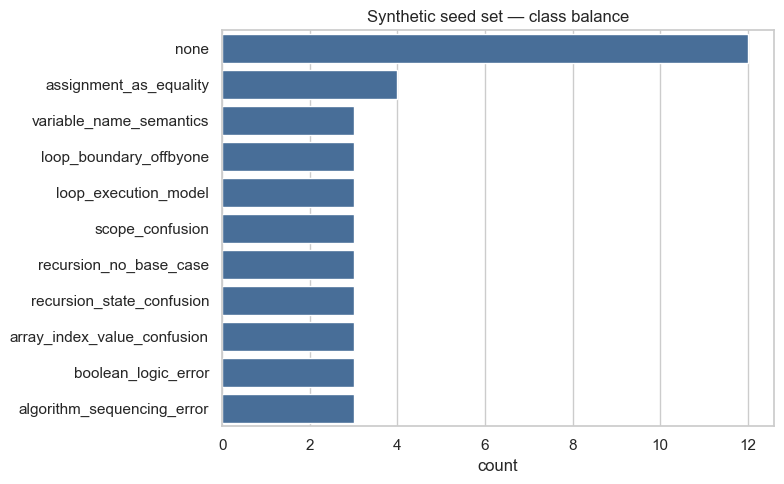

,concept,question,reference_answer,student_pseudocode_answer,is_correct,misconception_label,explanation,source
0,variables,Does the computer understand what the variable...,No — the name is only a label for humans; the ...,"Yes, because it is called 'total' the computer...",False,variable_name_semantics,Believes the computer reads meaning from the v...,synthetic_seed
1,variables,"If I rename 'speed' to 'x', does the program b...",No — names are arbitrary labels; behaviour dep...,"Yes, 'speed' makes it go faster than 'x' would.",False,variable_name_semantics,Attaches real-world meaning of the identifier ...,synthetic_seed
2,variables,A variable is named 'isReady'. What makes it t...,Whatever boolean value is assigned to it.,It is true automatically because the name says...,False,variable_name_semantics,Thinks the name 'isReady' sets the value rathe...,synthetic_seed
3,variables,x <- 3\ny <- x\nx <- 10\nWhat is y now?,3 — y received a copy of x's value at assignme...,y is 10 because y equals x and x became 10.,False,assignment_as_equality,Treats assignment as a permanent equation link...,synthetic_seed


In [10]:
seed_df = pd.DataFrame(SEED_ROWS)
seed_df["source"] = "synthetic_seed"
print(f"Seed rows: {len(seed_df)}")
print(f"Correct (none): {(seed_df.misconception_label == 'none').sum()}  |  "
      f"misconception rows: {(seed_df.misconception_label != 'none').sum()}")

fig, ax = plt.subplots(figsize=(8, 5))
order = seed_df["misconception_label"].value_counts().index
sns.countplot(data=seed_df, y="misconception_label", order=order, ax=ax, color="#3b6ea5")
ax.set_title("Synthetic seed set — class balance"); ax.set_xlabel("count"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(FIGURES / "seed_class_balance.png", dpi=120)
plt.show()
seed_df.head(4)

### C.2 (optional) Anthropic-API augmentation — *pending confirmation*

> 🔒 **API cell intentionally not included yet.** To avoid burning API calls
> unintentionally, the cell that generates additional synthetic rows with the
> Anthropic API (prompting Claude to answer as a novice holding each misconception)
> will be added after explicit confirmation. The notebook is fully runnable without
> it using the hand-authored seed above.

## D. Two classifiers on the seed set

- **Baseline:** TF-IDF + SVM on the synthetic seed set → precision / recall / F1.
- **LLM-as-classifier:** Claude predicts `misconception_label` from the fixed
  taxonomy on the *same* held-out split (the cell for this is API-gated — see
  below). This is exactly the slot the future **fine-tuned Qwen3.5-4B** drops into.

In [11]:
# --- Baseline: TF-IDF + LinearSVC on the seed set ---
# Small, multi-class, synthetic => expect modest, noisy numbers. That is the point:
# it establishes a floor that real data + a fine-tuned model must beat.
seed_text = (seed_df["question"].fillna("") + "  [SEP]  "
             + seed_df["student_pseudocode_answer"].fillna("")).tolist()
seed_y = seed_df["misconception_label"].tolist()

# Stratify where possible; fall back to a plain split for very small classes.
try:
    Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
        seed_text, seed_y, test_size=0.3, random_state=RANDOM_STATE, stratify=seed_y)
except ValueError:
    Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
        seed_text, seed_y, test_size=0.3, random_state=RANDOM_STATE)

baseline = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True),
    LinearSVC())
baseline.fit(Xtr_s, ytr_s)
pred_s = baseline.predict(Xte_s)

acc = accuracy_score(yte_s, pred_s)
p, r, f1 = precision_recall_fscore_support(yte_s, pred_s, average="macro", zero_division=0)[:3]
print(f"Seed baseline (TF-IDF + SVM)  acc={acc:.3f}  macro-P={p:.3f}  macro-R={r:.3f}  macro-F1={f1:.3f}")
print(f"Held-out test rows: {len(yte_s)}\n")
print(classification_report(yte_s, pred_s, zero_division=0))
metrics_summary["Seed: TF-IDF + SVM"] = {"accuracy": round(acc, 4), "macro_precision": round(p, 4),
                                         "macro_recall": round(r, 4), "macro_f1": round(f1, 4)}
# Persist the held-out split so the (later) LLM cell scores the SAME rows.
pd.DataFrame({"text": Xte_s, "label": yte_s}).to_json(FIGURES / "seed_holdout.json")

Seed baseline (TF-IDF + SVM)  acc=0.308  macro-P=0.239  macro-R=0.303  macro-F1=0.259
Held-out test rows: 13

                             precision    recall  f1-score   support

 algorithm_sequencing_error       0.00      0.00      0.00         1
array_index_value_confusion       0.00      0.00      0.00         1
     assignment_as_equality       0.00      0.00      0.00         1
        boolean_logic_error       0.00      0.00      0.00         1
     loop_boundary_offbyone       0.00      0.00      0.00         1
       loop_execution_model       0.50      1.00      0.67         1
                       none       0.12      0.33      0.18         3
     recursion_no_base_case       0.00      0.00      0.00         1
  recursion_state_confusion       1.00      1.00      1.00         1
            scope_confusion       0.00      0.00      0.00         1
    variable_name_semantics       1.00      1.00      1.00         1

                   accuracy                           0.31  

### D.2 LLM-as-classifier (Claude) — *pending confirmation*

> 🔒 **API cell intentionally not included yet.** The cell that calls the Anthropic
> API to predict `misconception_label` on the **same held-out split**
> (`figures/seed_holdout.json`) — and the side-by-side baseline-vs-LLM F1 plot —
> will be added after explicit confirmation. This is the experiment the future
> self-hosted **fine-tuned Qwen3.5-4B** will be benchmarked in.

## E. Conclusion

**What this notebook shows.**

1. **The pipeline works on real data.** On SciEntsBank (unseen-answers split), a
   TF-IDF + classifier pipeline reaches a **macro-F1 of 0.45** (best of
   LinearSVC / LogisticRegression / XGBoost) on a 5-way misconception-style target,
   with full precision / recall / F1 and a confusion matrix. This validates the
   data-viz → features → model → metrics workflow end to end.
2. **An initial baseline for our own task.** On the synthetic pseudocode-misconception
   seed set, a TF-IDF + SVM baseline reaches **macro-F1 0.26** on a held-out
   split across the fixed taxonomy. The LLM-as-classifier comparison (and the API
   augmentation of the seed set) are the API-gated cells, added on confirmation.

**Limitations (stated honestly).** The seed set is **synthetic and small (N≈43)**.
Its numbers are indicative only. There is no inter-annotator agreement yet, and the
class balance is hand-controlled rather than observed.

**Next steps.**
- Collect **real pilot data** from students and label it with **≥2 annotators**;
  report **Cohen's κ** before trusting any model trained on it.
- Expand the seed set toward the 80–120 row target via the Anthropic-API generation
  cell, then **fine-tune Qwen3.5-4B** as the production classifier and benchmark it
  against the frontier API and the baselines here. **Target: macro-F1 ≥ 0.80.**
- The LLM-as-classifier slot in §D is exactly where the fine-tuned model drops in —
  no pipeline changes needed.

In [12]:
# Save a machine-readable metrics summary for the README / conclusion.
with open(FIGURES / "metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)
print(json.dumps(metrics_summary, indent=2))

{
  "TF-IDF + LinearSVC": {
    "accuracy": 0.5611,
    "macro_precision": 0.4244,
    "macro_recall": 0.398,
    "macro_f1": 0.403
  },
  "TF-IDF + LogReg": {
    "accuracy": 0.463,
    "macro_precision": 0.3722,
    "macro_recall": 0.3898,
    "macro_f1": 0.3696
  },
  "TF-IDF + XGBoost": {
    "accuracy": 0.5944,
    "macro_precision": 0.4806,
    "macro_recall": 0.4377,
    "macro_f1": 0.4499
  },
  "Seed: TF-IDF + SVM": {
    "accuracy": 0.3077,
    "macro_precision": 0.2386,
    "macro_recall": 0.303,
    "macro_f1": 0.259
  }
}
